# 🏨 Phase 4 — Guest Segmentation
**Goal:** Analyze behavior, satisfaction, and complaints per guest type  
**Segments:** Solo Traveler · Couple · Family · Business · Group

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Libraries loaded')

✅ Libraries loaded


## 2. Load & Parse Tags

In [2]:
df = pd.read_csv(r"C:\Users\dimma\OneDrive\Υπολογιστής\Hotel 515\Hotel_Reviews.csv")
df['Negative_Review'] = df['Negative_Review'].replace('No Negative', '')
df['Positive_Review'] = df['Positive_Review'].replace('No Positive', '')
df['Hotel_Country'] = df['Hotel_Address'].apply(lambda x: x.split()[-1])
df['Review_Date'] = pd.to_datetime(df['Review_Date'])

# Parse the Tags column (e.g. "[' Leisure trip ', ' Couple ', ' Duplex Double Room ', '2 nights ']"
def extract_tags(tag_str):
    if not isinstance(tag_str, str): return []
    return [t.strip().strip("'\"") for t in re.findall(r"'([^']+)'", tag_str)]

df['tags_list'] = df['Tags'].apply(extract_tags)

# Extract trip type & traveler type
def extract_trip_type(tags):
    tags_lower = [t.lower() for t in tags]
    for t in tags_lower:
        if 'business' in t: return 'Business'
        if 'leisure' in t: return 'Leisure'
    return 'Unknown'

def extract_traveler_type(tags):
    tags_lower = [t.lower() for t in tags]
    for t in tags_lower:
        if 'solo' in t: return 'Solo'
        if 'couple' in t: return 'Couple'
        if 'family' in t: return 'Family'
        if 'group' in t: return 'Group'
        if 'friends' in t: return 'Friends'
    return 'Unknown'

def extract_nights(tags):
    for t in tags:
        m = re.search(r'(\d+)\s*night', t.lower())
        if m: return int(m.group(1))
    return np.nan

def extract_room_type(tags):
    for t in tags:
        t_low = t.lower()
        if 'suite' in t_low: return 'Suite'
        if 'deluxe' in t_low: return 'Deluxe'
        if 'standard' in t_low: return 'Standard'
        if 'superior' in t_low: return 'Superior'
        if 'twin' in t_low: return 'Twin'
        if 'double' in t_low: return 'Double'
        if 'single' in t_low: return 'Single'
    return 'Other'

df['trip_type']     = df['tags_list'].apply(extract_trip_type)
df['traveler_type'] = df['tags_list'].apply(extract_traveler_type)
df['nights']        = df['tags_list'].apply(extract_nights)
df['room_type']     = df['tags_list'].apply(extract_room_type)

print('✅ Tags parsed')
print('Traveler type distribution:')
print(df['traveler_type'].value_counts())

✅ Tags parsed
Traveler type distribution:
traveler_type
Couple     252294
Solo       108545
Family      87364
Group       65392
Friends      2143
Name: count, dtype: int64


## 3. Score by Traveler Type

               avg_score  median_score   count  avg_nights
traveler_type                                             
Couple              8.51           9.2  252294        2.31
Friends             8.50           9.2    2143        2.38
Group               8.45           8.8   65392        2.32
Family              8.34           8.8   87364        2.70
Solo                8.13           8.3  108545        2.24


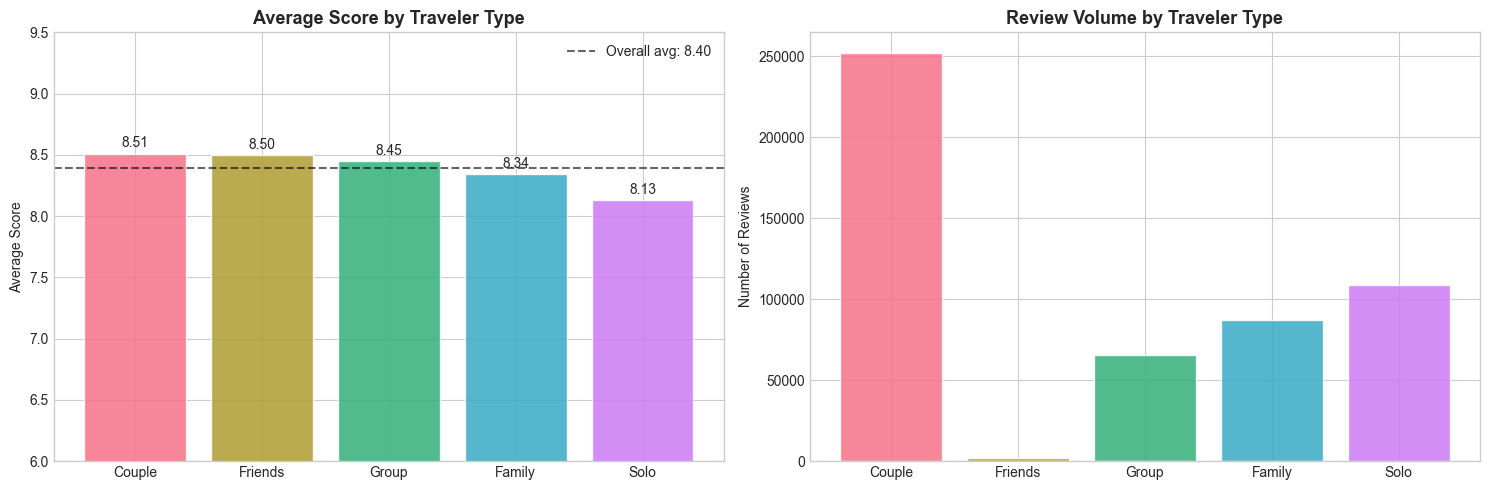

In [4]:
seg = df[df['traveler_type'] != 'Unknown'].copy()

seg_stats = seg.groupby('traveler_type').agg(
    avg_score=('Reviewer_Score', 'mean'),
    median_score=('Reviewer_Score', 'median'),
    count=('Reviewer_Score', 'count'),
    avg_nights=('nights', 'mean')
).round(2).sort_values('avg_score', ascending=False)

print(seg_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Avg score by segment
colors = sns.color_palette('husl', len(seg_stats))
axes[0].bar(seg_stats.index, seg_stats['avg_score'], color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(seg['Reviewer_Score'].mean(), color='black', linestyle='--',
                alpha=0.6, label=f'Overall avg: {seg["Reviewer_Score"].mean():.2f}')
axes[0].set_title('Average Score by Traveler Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Score')
axes[0].set_ylim(6, 9.5)
axes[0].legend()
for i, (idx, row) in enumerate(seg_stats.iterrows()):
    axes[0].text(i, row['avg_score'] + 0.05, f'{row["avg_score"]:.2f}', ha='center', fontsize=10)

# Review volume by segment
axes[1].bar(seg_stats.index, seg_stats['count'], color=colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Review Volume by Traveler Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Reviews')

plt.tight_layout()

plt.show()

## 4. Score Distribution per Segment (Boxplot)

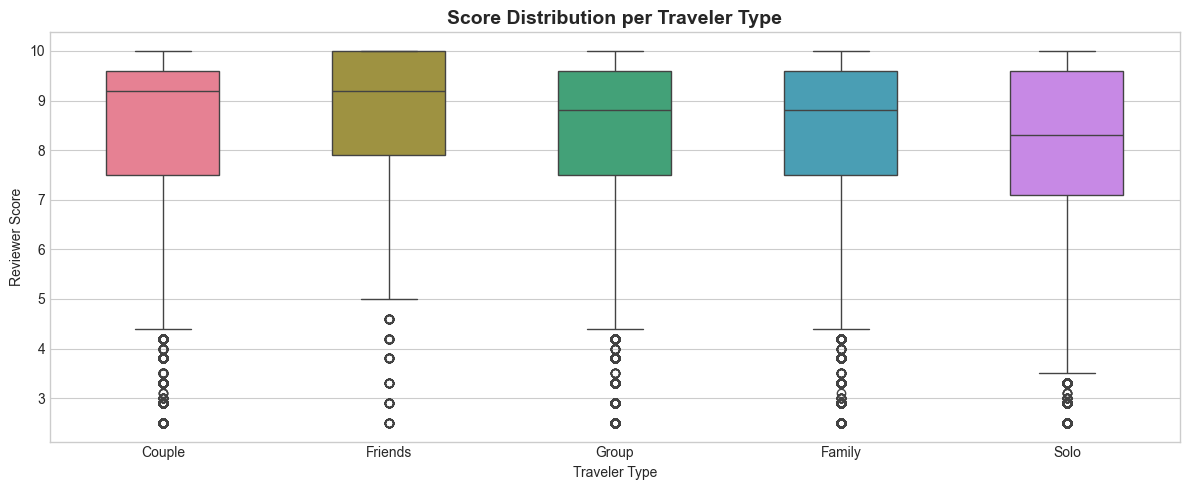

In [5]:
plt.figure(figsize=(12, 5))
order = seg.groupby('traveler_type')['Reviewer_Score'].mean().sort_values(ascending=False).index
sns.boxplot(data=seg, x='traveler_type', y='Reviewer_Score',
            order=order, palette='husl', width=0.5)
plt.title('Score Distribution per Traveler Type', fontsize=14, fontweight='bold')
plt.xlabel('Traveler Type')
plt.ylabel('Reviewer Score')
plt.tight_layout()

plt.show()

## 5. Top Complaints per Segment

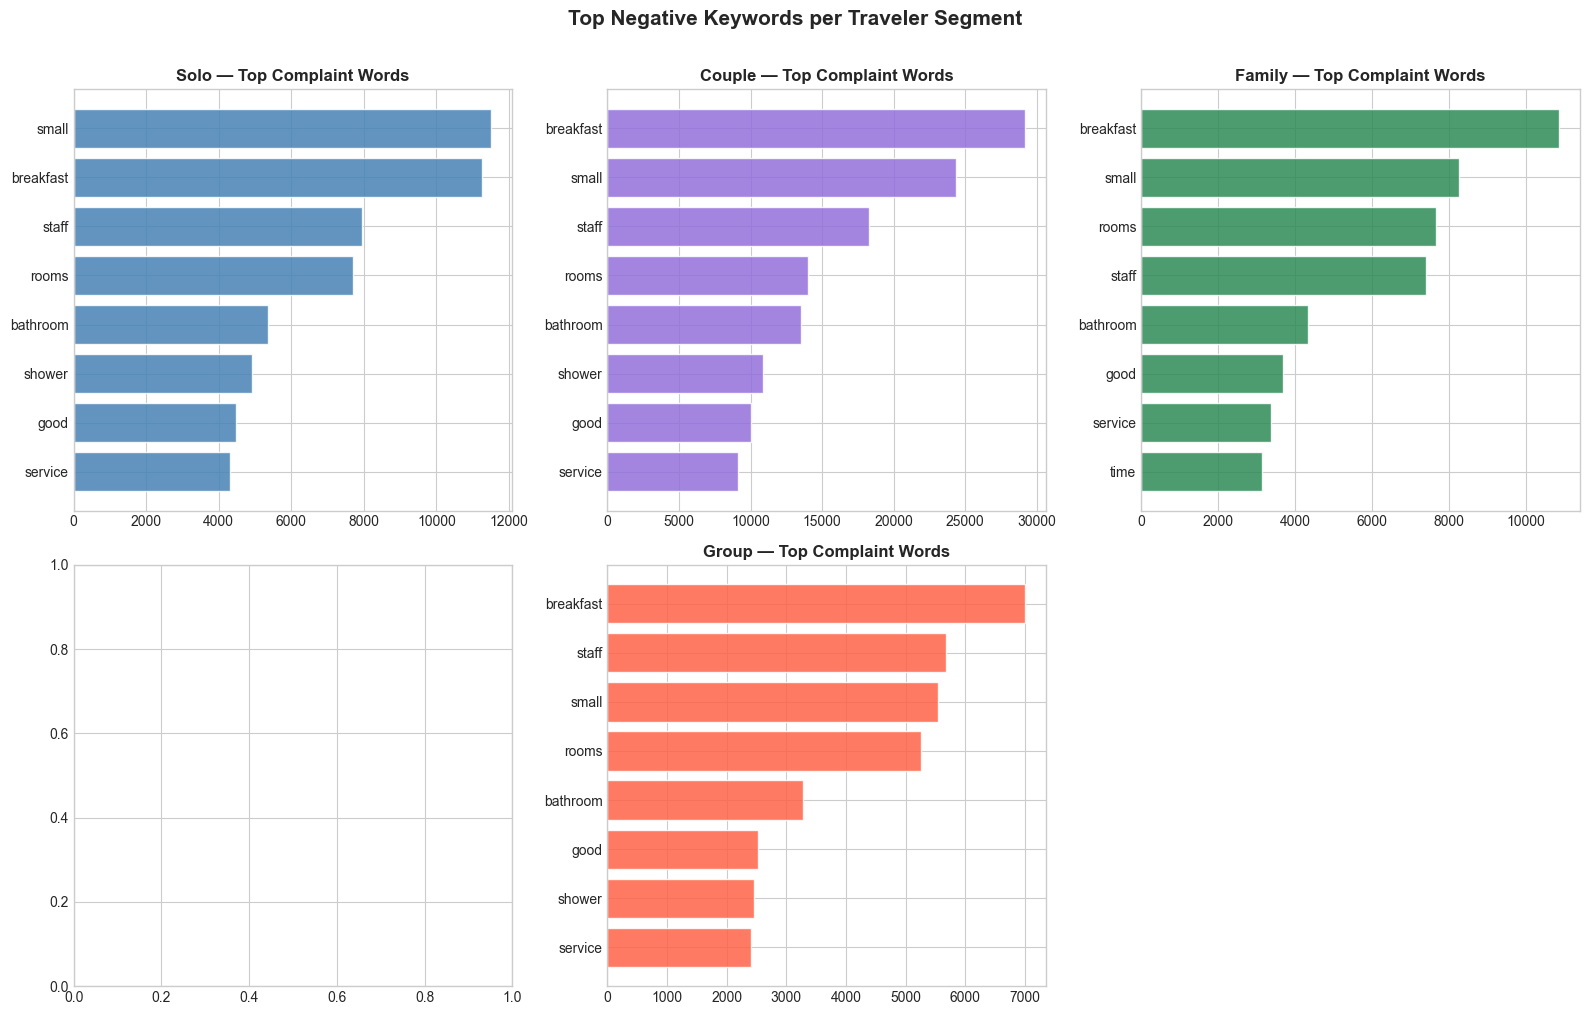

In [6]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
stop_words.update(['hotel', 'room', 'nothing', 'really', 'bit', 'little',
                   'just', 'also', 'would', 'like', 'stay', 'night', 'could'])

def top_words(texts, n=8):
    all_words = []
    for t in texts:
        if isinstance(t, str):
            words = [w.lower() for w in t.split() if w.isalpha()
                     and w.lower() not in stop_words and len(w) > 3]
            all_words.extend(words)
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

segments = ['Solo', 'Couple', 'Family', 'Business', 'Group']
colors_map = {'Solo': 'steelblue', 'Couple': 'mediumpurple', 'Family': 'seagreen',
              'Business': 'darkorange', 'Group': 'tomato'}

for idx, segment in enumerate(segments):
    subset = seg[seg['traveler_type'] == segment]['Negative_Review']
    top = top_words(subset, n=8)
    if top:
        words, counts = zip(*top)
        axes[idx].barh(words, counts, color=colors_map[segment], alpha=0.85)
        axes[idx].set_title(f'{segment} — Top Complaint Words', fontweight='bold')
        axes[idx].invert_yaxis()

axes[-1].axis('off')
plt.suptitle('Top Negative Keywords per Traveler Segment', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

plt.show()

## 6. Business vs Leisure — Deep Dive

=== Business vs Leisure ===
           avg_score   count  avg_nights
trip_type                               
Business        7.97   82972        2.22
Leisure         8.49  417778        2.39



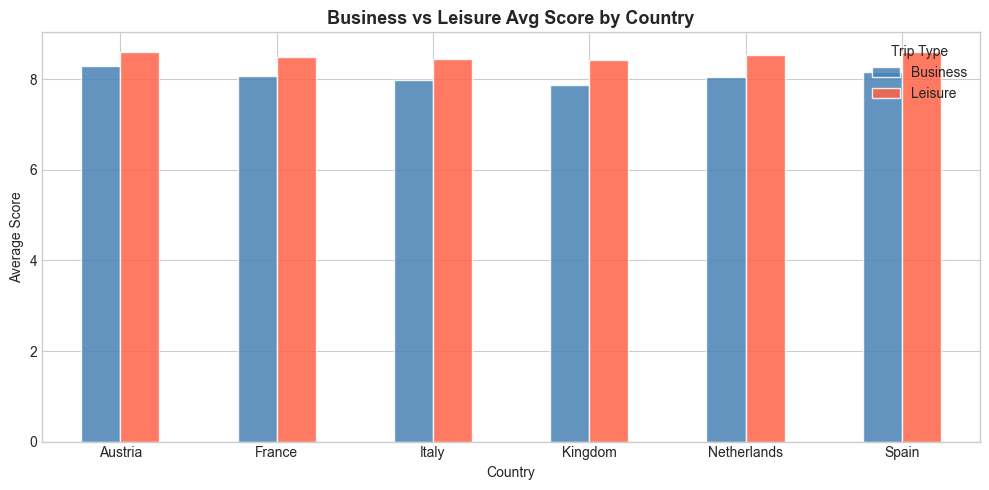

In [7]:
trip_seg = df[df['trip_type'] != 'Unknown'].copy()

trip_stats = trip_seg.groupby('trip_type').agg(
    avg_score=('Reviewer_Score', 'mean'),
    count=('Reviewer_Score', 'count'),
    avg_nights=('nights', 'mean')
).round(2)

print('=== Business vs Leisure ===')
print(trip_stats)
print()

# Score by trip type AND country
pivot = trip_seg.groupby(['Hotel_Country', 'trip_type'])['Reviewer_Score'].mean().unstack()
pivot.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'tomato'], alpha=0.85, edgecolor='white')
plt.title('Business vs Leisure Avg Score by Country', fontsize=13, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.legend(title='Trip Type')
plt.tight_layout()

plt.show()

## 7. Length of Stay Analysis

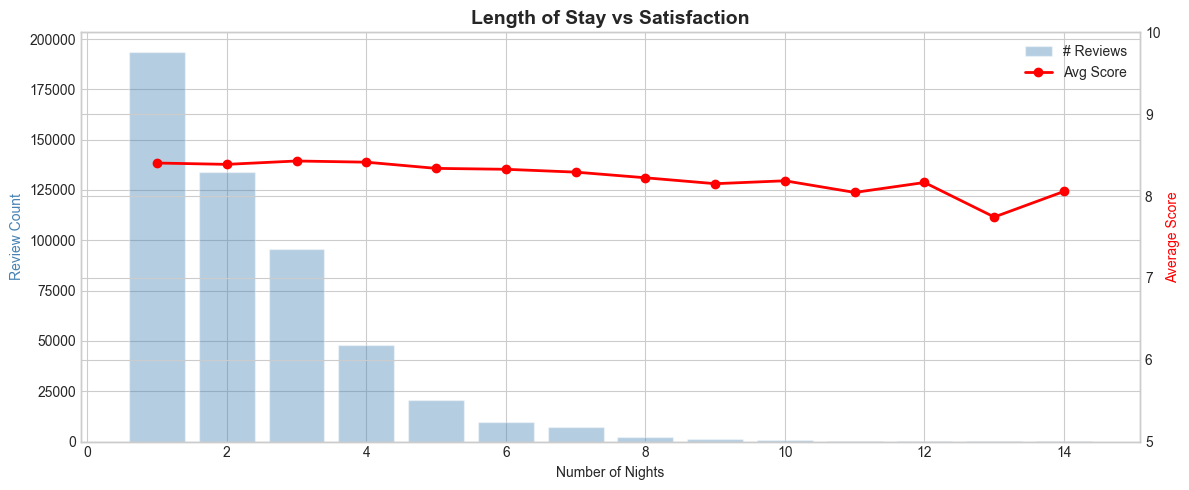

✅ Phase 4 Complete! → Proceed to 05_KPI_Dashboard.ipynb


In [8]:
stay_df = df.dropna(subset=['nights']).copy()
stay_df = stay_df[stay_df['nights'] <= 14]  # Remove outliers

stay_score = stay_df.groupby('nights')['Reviewer_Score'].mean()
stay_count = stay_df.groupby('nights').size()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(stay_score.index, stay_count.values, color='steelblue', alpha=0.4, label='# Reviews')
ax2.plot(stay_score.index, stay_score.values, color='red', marker='o', linewidth=2, label='Avg Score')

ax1.set_title('Length of Stay vs Satisfaction', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Nights')
ax1.set_ylabel('Review Count', color='steelblue')
ax2.set_ylabel('Average Score', color='red')
ax2.set_ylim(5, 10)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='upper right')

plt.tight_layout()

plt.show()

print('✅ Phase 4 Complete! → Proceed to 05_KPI_Dashboard.ipynb')